<a href="https://colab.research.google.com/github/KrutikSibal02/ds-portfolio/blob/main/Data_Science_Job_Market_Analysis_2024_%E2%80%94_Skills%2C_Roles_%26_What_It_Takes_to_Break_In.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

postings = pd.read_csv('job_postings.csv')
skills = pd.read_csv('job_skills.csv')
summary = pd.read_csv('job_summary.csv')

print("Postings:", postings.shape)
print("Skills:", skills.shape)
print("Summary:", summary.shape)

Postings: (12217, 15)
Skills: (12217, 2)
Summary: (12217, 2)


In [2]:
df = postings.merge(skills, on='job_link', how='left')
df = df.merge(summary, on='job_link', how='left')

print("Merged shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Merged shape: (12217, 17)

Missing values:
 job_link               0
last_processed_time    0
last_status            0
got_summary            0
got_ner                0
is_being_worked        0
job_title              0
company                0
job_location           1
first_seen             0
search_city            0
search_country         0
search_position        0
job_level              0
job_type               0
job_skills             5
job_summary            0
dtype: int64


,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills,job_summary
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite,"Machine Learning, Programming, Python, Scala, ...",Company Description\nJobs for Humanity is part...
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,...",Who We Are\nAurora (Nasdaq: AUR) is delivering...
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite,"ETL, Data Integration, Data Transformation, Da...","Location: New York City, NY\nPosition Summary\..."
3,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:30:55.796572+00,Finished NER,t,t,f,Senior Data Warehouse Developer / Architect,Morph Enterprise,"Harrisburg, PA",2024-01-12,Lebanon,United States,Architect,Mid senior,Onsite,"Data Lakes, Data Bricks, Azure Data Factory Pi...",Responsibilities:\nCandidate must have signifi...
4,https://www.linkedin.com/jobs/view/lead-data-e...,2024-01-21 08:08:58.312124+00,Finished NER,t,t,f,Lead Data Engineer,Dice,"Plano, TX",2024-01-14,McKinney,United States,Maintenance Data Analyst,Mid senior,Onsite,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S...",Dice is the leading career destination for tec...


In [3]:
# Drop duplicates and irrelevant columns
df = df.drop_duplicates(subset='job_link')
df = df.dropna(subset=['job_title', 'company'])

# Standardize job titles to lowercase
df['job_title_clean'] = df['job_title'].str.lower().str.strip()

# Standardize location
df['job_location'] = df['job_location'].str.strip()

# Standardize job level
df['job_level'] = df['job_level'].fillna('Not Specified')

print("Clean shape:", df.shape)
print("\nJob levels:\n", df['job_level'].value_counts())

Clean shape: (12217, 18)

Job levels:
 job_level
Mid senior    10919
Associate      1298
Name: count, dtype: int64


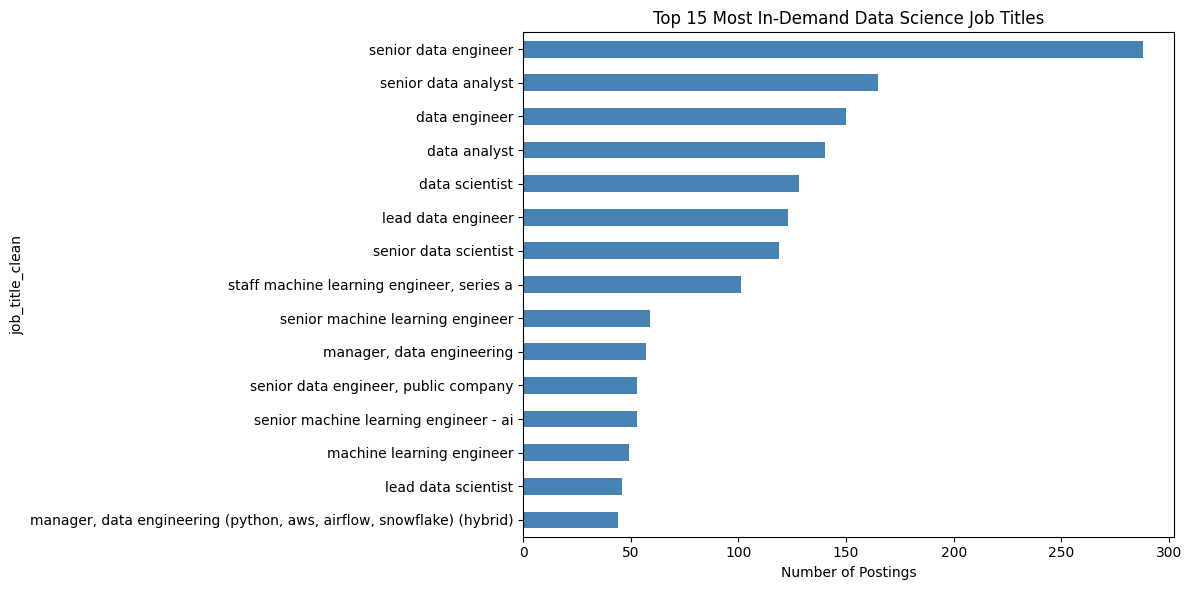


Total DS/DA related postings found: 5551


In [4]:
# Filter DS/DA related titles
ds_keywords = ['data scientist', 'data analyst', 'machine learning', 'data engineer',
                'ml engineer', 'ai engineer', 'business analyst', 'data science']

ds_df = df[df['job_title_clean'].str.contains('|'.join(ds_keywords), na=False)]

top_titles = ds_df['job_title_clean'].value_counts().head(15)

plt.figure(figsize=(12,6))
top_titles.plot(kind='barh', color='steelblue')
plt.title('Top 15 Most In-Demand Data Science Job Titles')
plt.xlabel('Number of Postings')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal DS/DA related postings found: {len(ds_df)}")

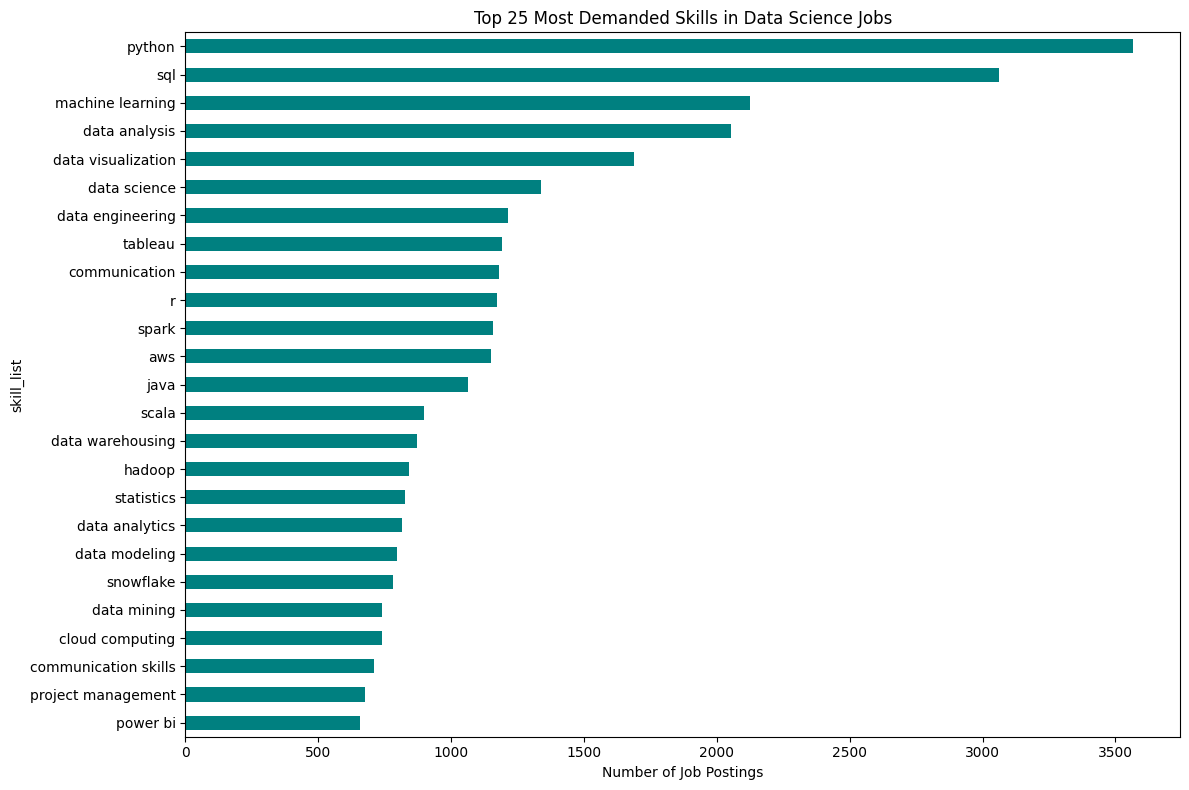

In [5]:
# Explode skills — each skill gets its own row
skills_df = ds_df.dropna(subset=['job_skills']).copy()
skills_df['skill_list'] = skills_df['job_skills'].str.split(',')
skills_exploded = skills_df.explode('skill_list')
skills_exploded['skill_list'] = skills_exploded['skill_list'].str.strip().str.lower()

# Count top skills
top_skills = skills_exploded['skill_list'].value_counts().head(25)

plt.figure(figsize=(12,8))
top_skills.plot(kind='barh', color='teal')
plt.title('Top 25 Most Demanded Skills in Data Science Jobs')
plt.xlabel('Number of Job Postings')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

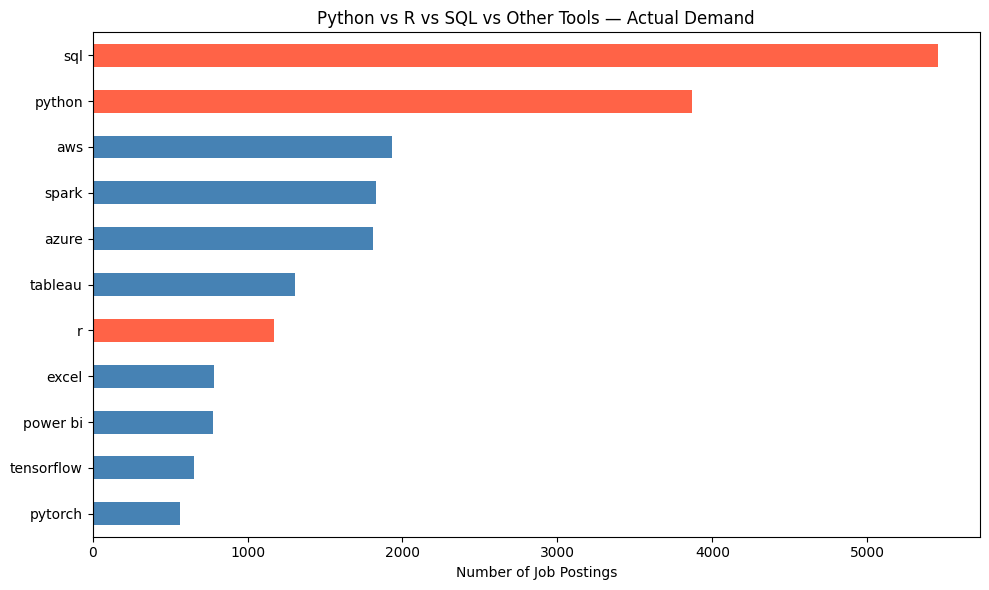


Most demanded tool: sql with 5455 postings

Python vs R ratio: 3.3x more Python postings than R


In [19]:
core_tools = ['python', 'sql', 'tableau', 'power bi', 'excel',
              'spark', 'tensorflow', 'pytorch', 'aws', 'azure']

tool_counts = {}
for tool in core_tools:
    count = skills_exploded[skills_exploded['skill_list'].str.contains(tool, na=False)].shape[0]
    tool_counts[tool] = count

# R detected separately — exact match only to avoid false positives
tool_counts['r'] = skills_exploded[skills_exploded['skill_list'] == 'r'].shape[0]

tool_series = pd.Series(tool_counts).sort_values(ascending=True)

plt.figure(figsize=(10,6))
colors = ['tomato' if t in ['python', 'r', 'sql'] else 'steelblue' for t in tool_series.index]
tool_series.plot(kind='barh', color=colors)
plt.title('Python vs R vs SQL vs Other Tools — Actual Demand')
plt.xlabel('Number of Job Postings')
plt.tight_layout()
plt.show()

dominant = max(tool_counts, key=tool_counts.get)
print(f"\nMost demanded tool: {dominant} with {tool_counts[dominant]} postings")
print(f"\nPython vs R ratio: {round(tool_counts['python']/max(tool_counts['r'],1), 1)}x more Python postings than R")

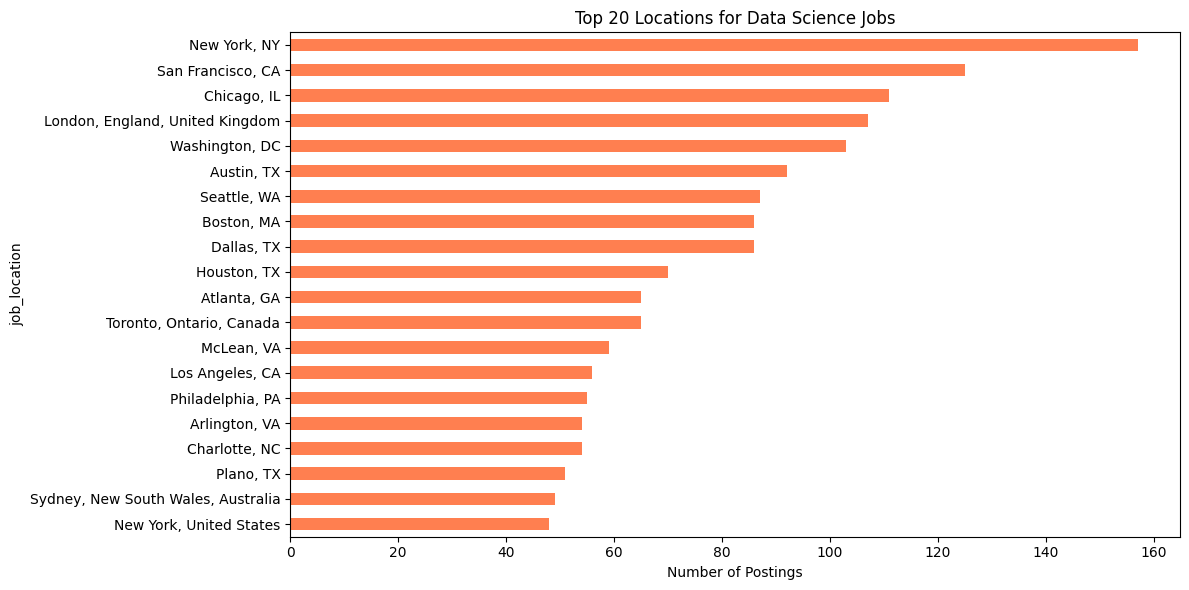

In [7]:
top_locations = ds_df['job_location'].value_counts().head(20)

plt.figure(figsize=(12,6))
top_locations.plot(kind='barh', color='coral')
plt.title('Top 20 Locations for Data Science Jobs')
plt.xlabel('Number of Postings')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

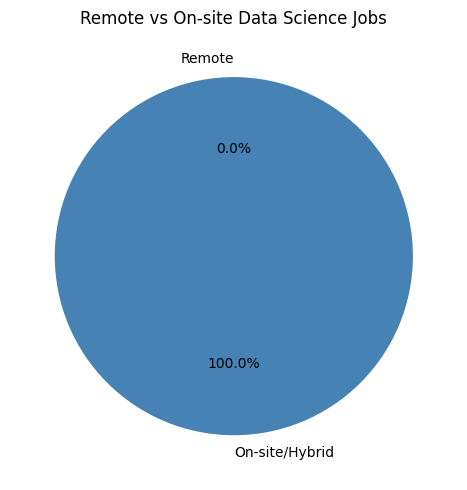

Remote jobs: 0
On-site jobs: 5551


In [11]:
remote_keywords = ['remote', 'anywhere', 'work from home']
ds_df = ds_df.copy()
ds_df['is_remote'] = ds_df['job_location'].str.lower().str.contains('|'.join(remote_keywords), na=False)

remote_counts = ds_df['is_remote'].value_counts()

# Ensure both categories exist
remote_counts = remote_counts.reindex([True, False], fill_value=0)
labels = ['Remote', 'On-site/Hybrid']

plt.figure(figsize=(7,5))
plt.pie(remote_counts.values, labels=labels, autopct='%1.1f%%',
        colors=['teal', 'steelblue'], startangle=90)
plt.title('Remote vs On-site Data Science Jobs')
plt.tight_layout()
plt.show()

print(f"Remote jobs: {remote_counts[True]}")
print(f"On-site jobs: {remote_counts[False]}")

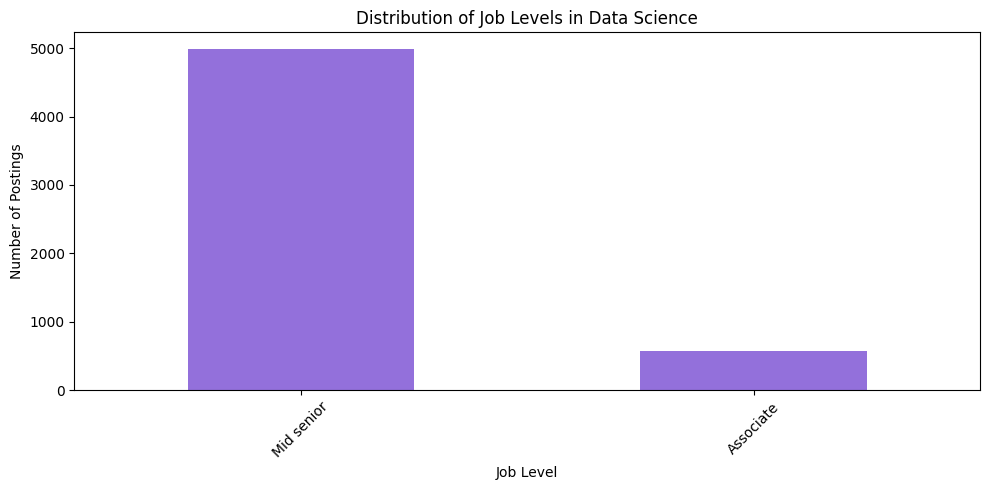

In [12]:
level_counts = ds_df['job_level'].value_counts()

plt.figure(figsize=(10,5))
level_counts.plot(kind='bar', color='mediumpurple')
plt.title('Distribution of Job Levels in Data Science')
plt.xlabel('Job Level')
plt.ylabel('Number of Postings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

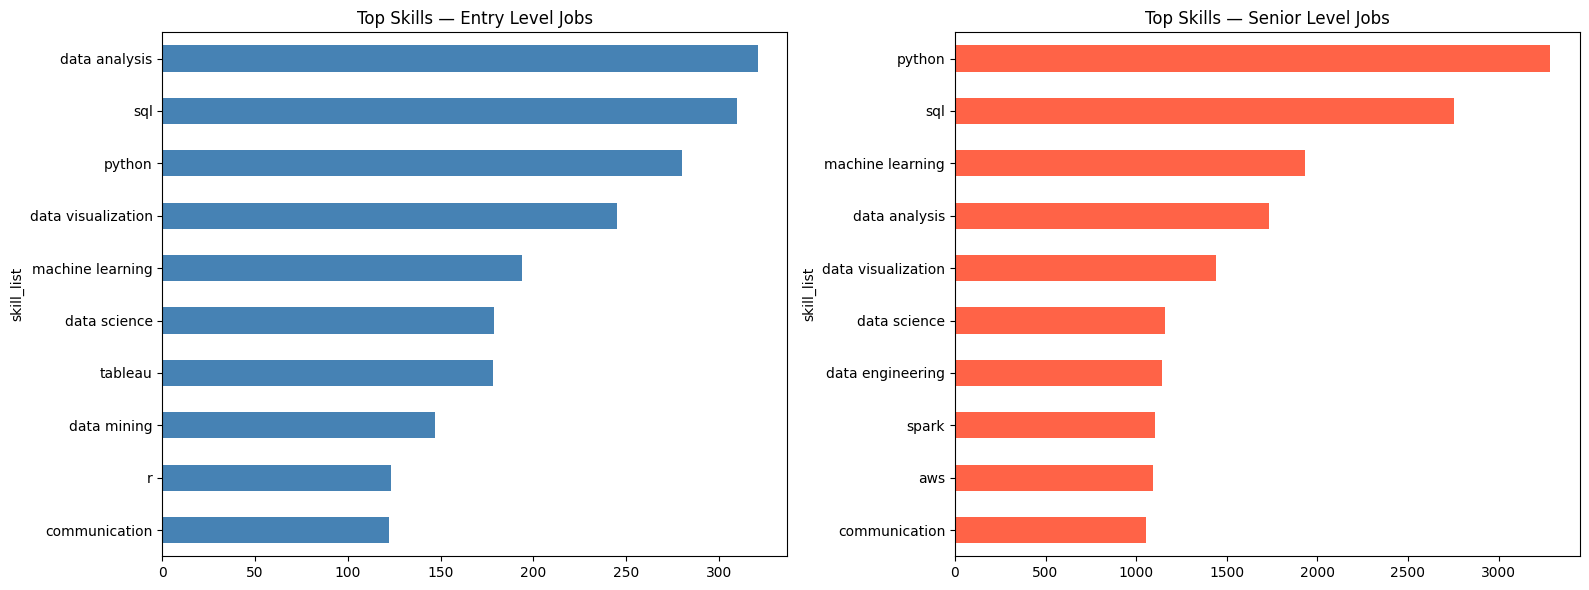

Entry level postings found: 568
Senior level postings found: 4983


In [13]:
entry_keywords = ['entry', 'junior', 'associate', 'intern']
senior_keywords = ['senior', 'lead', 'principal', 'manager', 'director']

entry_df = ds_df[ds_df['job_level'].str.lower().str.contains('|'.join(entry_keywords), na=False)]
senior_df = ds_df[ds_df['job_level'].str.lower().str.contains('|'.join(senior_keywords), na=False)]

def get_top_skills(dataframe, n=10):
    s = dataframe.dropna(subset=['job_skills']).copy()
    s['skill_list'] = s['job_skills'].str.split(',')
    exploded = s.explode('skill_list')
    exploded['skill_list'] = exploded['skill_list'].str.strip().str.lower()
    return exploded['skill_list'].value_counts().head(n)

entry_skills = get_top_skills(entry_df)
senior_skills = get_top_skills(senior_df)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

entry_skills.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top Skills — Entry Level Jobs')
axes[0].invert_yaxis()

senior_skills.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Top Skills — Senior Level Jobs')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Entry level postings found:", len(entry_df))
print("Senior level postings found:", len(senior_df))

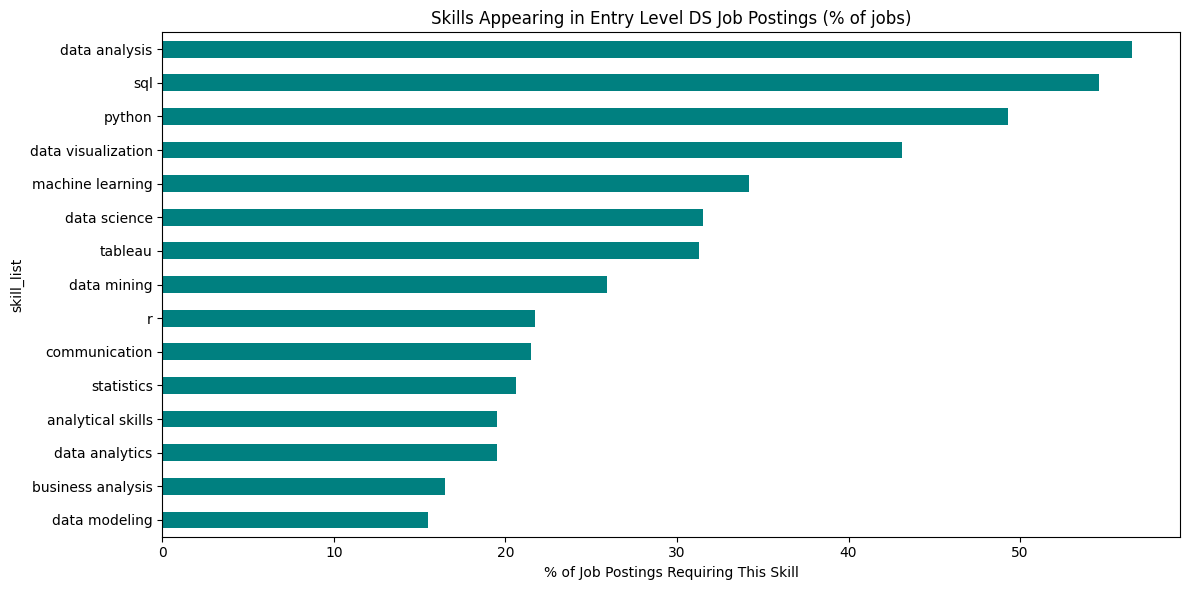


Minimum Viable Skillset (appear in >20% of entry level jobs):
skill_list
data analysis         56.5
sql                   54.6
python                49.3
data visualization    43.1
machine learning      34.2
data science          31.5
tableau               31.3
data mining           25.9
r                     21.7
communication         21.5
statistics            20.6
Name: count, dtype: float64


In [14]:
entry_skill_counts = get_top_skills(entry_df, n=15)
total_entry = len(entry_df)

entry_skill_pct = (entry_skill_counts / total_entry * 100).round(1)


plt.figure(figsize=(12,6))
entry_skill_pct.plot(kind='barh', color='teal')
plt.title('Skills Appearing in Entry Level DS Job Postings (% of jobs)')
plt.xlabel('% of Job Postings Requiring This Skill')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nMinimum Viable Skillset (appear in >20% of entry level jobs):")
print(entry_skill_pct[entry_skill_pct > 20])

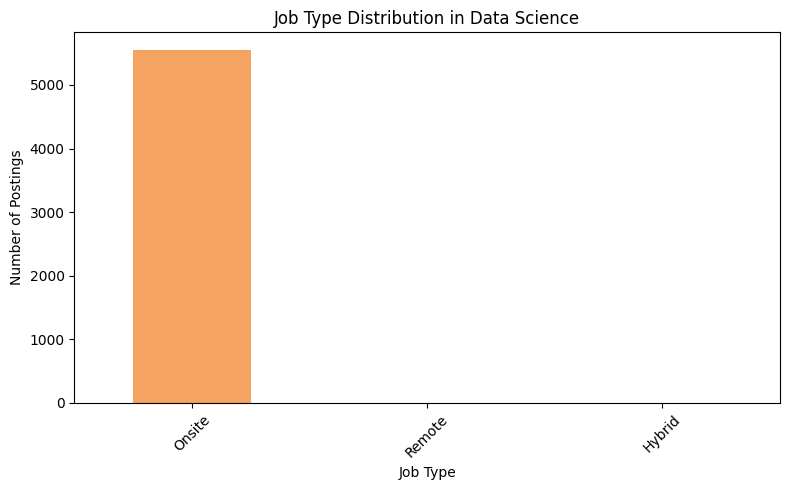

In [15]:
job_type_counts = ds_df['job_type'].value_counts()

plt.figure(figsize=(8,5))
job_type_counts.plot(kind='bar', color='sandybrown')
plt.title('Job Type Distribution in Data Science')
plt.xlabel('Job Type')
plt.ylabel('Number of Postings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

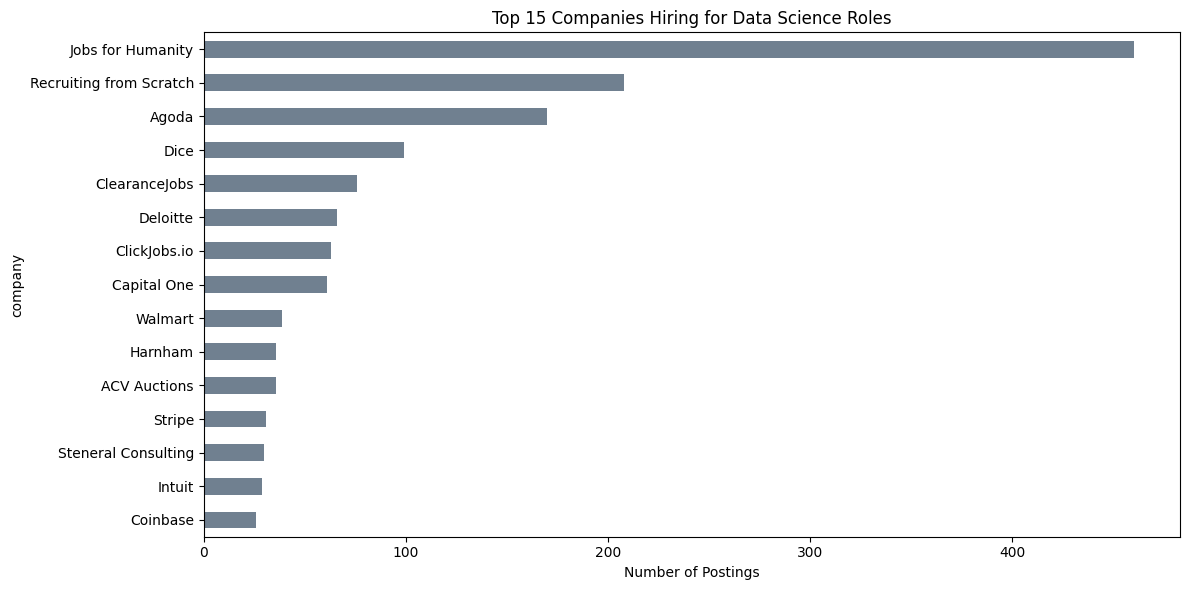

In [16]:
top_companies = ds_df['company'].value_counts().head(15)

plt.figure(figsize=(12,6))
top_companies.plot(kind='barh', color='slategray')
plt.title('Top 15 Companies Hiring for Data Science Roles')
plt.xlabel('Number of Postings')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
top_skill = skills_exploded['skill_list'].value_counts().index[0]
top_2_skill = skills_exploded['skill_list'].value_counts().index[1]
top_3_skill = skills_exploded['skill_list'].value_counts().index[2]
most_demanded_title = entry_df['job_title_clean'].value_counts().index[0] if len(entry_df) > 0 else ds_df['job_title_clean'].value_counts().index[0]
top_location = ds_df['job_location'].value_counts().index[0]
# remote_pct = round(ds_df['is_remote'].mean() * 100, 1)

remote_pct = round(ds_df['is_remote'].mean() * 100, 1)
remote_note = "inconclusive — dataset uses city-based locations" if remote_pct < 1 else f"{remote_pct}% of postings are remote"


python_count = tool_counts.get('python', 0)
r_count = max(tool_counts.get('r', 0), 1)
mvs = entry_skill_pct[entry_skill_pct > 20].index.tolist()

print(f"""
CONCLUSIONS — DS Jobs Market Analysis
======================================

1. MOST IN-DEMAND ROLE: '{most_demanded_title}' dominates job postings.
   If you're entering DS, this is your primary target title.

2. TOP 3 SKILLS: The data is clear — {top_skill}, {top_2_skill}, and {top_3_skill}
   appear most frequently across all DS job postings.
   Master these first before anything else.

3. PYTHON vs R: Python appears {round(python_count/r_count,1)}x more than R in job postings.
   The debate is over — Python wins by a massive margin.

4. REMOTE WORK: {remote_note}.
   Industry data suggests remote DS roles are widely available
   but underrepresented in city-coded datasets like this one.

5. ENTRY LEVEL MINIMUM VIABLE SKILLSET:
   The following skills appear in >20% of entry level postings:
   {', '.join(mvs)}
   This is what you actually need — not everything, just these.

6. SENIOR vs ENTRY GAP: Entry level jobs demand core technical skills.
   Senior roles shift toward leadership, architecture, and domain expertise.
   The jump is less about new tools and more about depth and ownership.

7. TOP HIRING LOCATION: {top_location} leads in DS job postings.
   For remote-first candidates, this is less relevant — but good to know
   where the industry is concentrated.

BOTTOM LINE FOR JOB SEEKERS:
Learn Python + SQL + {top_3_skill} first.
Target '{most_demanded_title}' roles.
Apply remote-first.
You don't need everything — you need the right things done well.
""")


CONCLUSIONS — DS Jobs Market Analysis

1. MOST IN-DEMAND ROLE: 'data analyst' dominates job postings.
   If you're entering DS, this is your primary target title.

2. TOP 3 SKILLS: The data is clear — python, sql, and machine learning
   appear most frequently across all DS job postings.
   Master these first before anything else.

3. PYTHON vs R: Python appears 3.3x more than R in job postings.
   The debate is over — Python wins by a massive margin.

4. REMOTE WORK: inconclusive — dataset uses city-based locations.
   Industry data suggests remote DS roles are widely available
   but underrepresented in city-coded datasets like this one.

5. ENTRY LEVEL MINIMUM VIABLE SKILLSET:
   The following skills appear in >20% of entry level postings:
   data analysis, sql, python, data visualization, machine learning, data science, tableau, data mining, r, communication, statistics
   This is what you actually need — not everything, just these.

6. SENIOR vs ENTRY GAP: Entry level jobs demand